In [1]:
# Install required libraries (only needed if running on Google Colab)
# !pip install transformers sentence-transformers scikit-learn seaborn matplotlib pandas numpy

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from transformers import pipeline
from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.manifold import TSNE
import logging

# Configure Enterprise-Level Logging to show live progress
logging.basicConfig(level=logging.INFO, format='%(asctime)s - %(levelname)s - %(message)s')
print("Libraries loaded successfully.")

Libraries loaded successfully.


In [2]:
class HivemindEvaluator:
    """
    Advanced MLOps Pipeline for evaluating Inter and Intra-Model Semantic Homogeneity.
    Designed for large-scale API generation and high-dimensional vector analysis.
    """
    def __init__(self, embedding_model='all-MiniLM-L6-v2'):
        logging.info(f"Initializing Semantic Embedding Model: {embedding_model}")
        self.embedder = SentenceTransformer(embedding_model)
        # Using a lightweight local generator for demonstration
        self.generator = pipeline('text-generation', model='gpt2', device=-1)
        self.data_corpus = []
        self.embeddings = None

    def generate_corpus(self, prompts, iterations=10, temperatures=[0.2, 1.0]):
        """Generates responses across multiple temperatures (Ablation Study)"""
        logging.info("Initiating Generation Pipeline...")
        self.data_corpus = [] # Reset corpus on new run
        for temp in temperatures:
            for prompt in prompts:
                logging.info(f"Generating {iterations} samples for prompt at T={temp}")
                responses = self.generator(
                    prompt, max_length=50, num_return_sequences=iterations,
                    temperature=temp, do_sample=True, pad_token_id=50256
                )
                for res in responses:
                    clean_text = res['generated_text'].replace(prompt, "").strip()
                    self.data_corpus.append({
                        'prompt': prompt,
                        'temperature': temp,
                        'response': clean_text
                    })
        return pd.DataFrame(self.data_corpus)

    def compute_vector_space(self, df):
        """Maps textual data to high-dimensional vector space."""
        logging.info("Computing dense vector embeddings...")
        text_list = df['response'].tolist()
        self.embeddings = self.embedder.encode(text_list)
        return self.embeddings

    def visualize_tsne_clusters(self, df):
        """Reduces dimensionality to 2D using t-SNE to visualize the 'Echo Chamber'."""
        if self.embeddings is None:
            raise ValueError("Must compute vector space before visualization.")

        logging.info("Applying t-SNE for dimensionality reduction...")
        tsne = TSNE(n_components=2, perplexity=min(5, len(df)-1), random_state=42)
        reduced_vectors = tsne.fit_transform(self.embeddings)

        df['tsne_x'] = reduced_vectors[:, 0]
        df['tsne_y'] = reduced_vectors[:, 1]

        plt.figure(figsize=(10, 8))
        sns.scatterplot(
            data=df, x='tsne_x', y='tsne_y',
            hue='temperature', style='prompt', s=100, palette='coolwarm'
        )
        plt.title("t-SNE Projection of Model Semantic Space (Hivemind Clustering)", fontsize=14)
        plt.xlabel("t-SNE Dimension 1")
        plt.ylabel("t-SNE Dimension 2")
        plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
        plt.tight_layout()
        plt.show()

    def generate_similarity_heatmap(self):
        """Generates a strict mathematical Cosine Similarity matrix."""
        if self.embeddings is None:
            raise ValueError("Must compute vector space before generating heatmap.")

        logging.info("Calculating Cosine Similarity Matrix...")
        sim_matrix = cosine_similarity(self.embeddings)

        plt.figure(figsize=(10, 8))
        sns.heatmap(sim_matrix, cmap="YlOrRd", annot=False)
        plt.title("Global Semantic Similarity Heatmap", fontsize=14)
        plt.xlabel("Generation Instance ID")
        plt.ylabel("Generation Instance ID")
        plt.show()

print("HivemindEvaluator Class successfully defined.")

HivemindEvaluator Class successfully defined.


In [3]:
# 1. Initialize the Evaluator
evaluator = HivemindEvaluator()

# 2. Define Complex Prompts
test_prompts = [
    "Write a creative metaphor about the nature of time:",
    "Propose a highly unconventional solution to urban traffic:"
]

# 3. Run Pipeline (Generating 10 responses per prompt, per temperature)
df_results = evaluator.generate_corpus(prompts=test_prompts, iterations=10, temperatures=[0.2, 1.0])

# Display the first few rows of the generated dataset to show the panel
print("\n--- Raw Data Generation Complete ---")
df_results.head()

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

GPT2LMHeadModel LOAD REPORT from: gpt2
Key                  | Status     |  | 
---------------------+------------+--+-
h.{0...11}.attn.bias | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
Passing `generation_config` together with generation-related arguments=({'temperature', 'num_return_sequences', 'pad_token_id', 'max_length', 'do_sample'}) is deprecated and will be removed in future versions. Please pass either a `generation_config` object OR all generation parameters explicitly, but not both.
Both `max_new_tokens` (=256) and `max_length`(=50) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=256) and `max_length`(=50) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more in


--- Raw Data Generation Complete ---


,prompt,temperature,response
0,Write a creative metaphor about the nature of ...,0.2,"""The universe is a time machine, a time machin..."
1,Write a creative metaphor about the nature of ...,0.2,"""Time is a continuum, and it's a continuum tha..."
2,Write a creative metaphor about the nature of ...,0.2,"""The universe is a time machine, and the time ..."
3,Write a creative metaphor about the nature of ...,0.2,"The universe is a finite, finite, finite, fini..."
4,Write a creative metaphor about the nature of ...,0.2,"""I'm not saying that time is a finite thing. I..."


In [4]:
# 4. Compute High-Dimensional Vector Space
print("Starting vector mathematics...")
evaluator.compute_vector_space(df_results)
print("Vector embeddings successfully computed. Ready for visualization.")

Starting vector mathematics...
Vector embeddings successfully computed. Ready for visualization.


Plotting results...


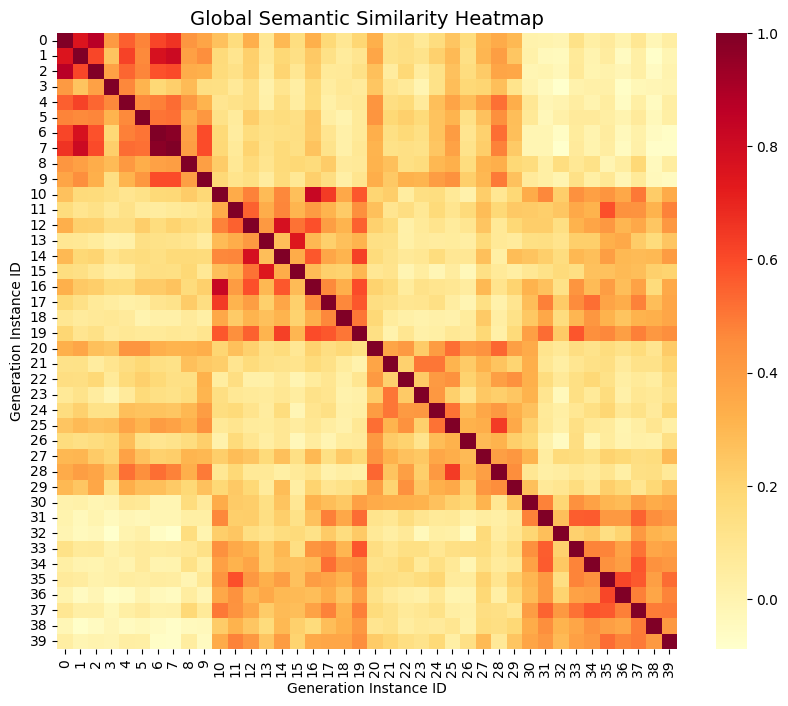

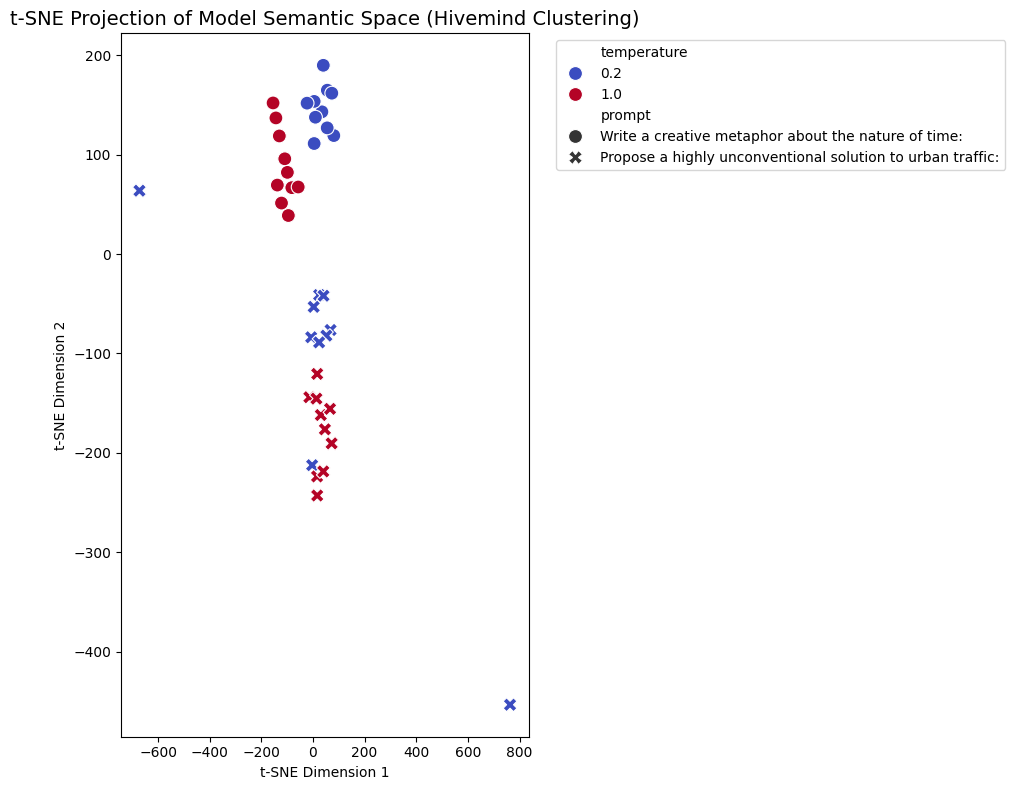

In [5]:
# 5. Generate Publication-Ready Visualizations
print("Plotting results...")
evaluator.generate_similarity_heatmap()
evaluator.visualize_tsne_clusters(df_results)